# Trust Duel: Person vs Agent

A reinforcement learning inspired game based on the **Iterated Prisoner's Dilemma**.

The goal is to compare fixed strategies and a learning agent in a repeated decision-making environment.


## 1. Project Introduction

In this project, we model a simple repeated game where each player chooses one of two actions:

- `C` = Cooperate
- `D` = Defect

The reward depends on both players' actions.

This is useful for reinforcement learning because the game has:

| RL Concept | In This Game |
|---|---|
| Agent | Strategy or Q-learning player |
| Environment | Game rules and payoff matrix |
| State | Previous actions |
| Action | Cooperate or Defect |
| Reward | Coins from the payoff matrix |
| Episode | A repeated match |
| Policy | The rule used to choose actions |


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.game import PAYOFFS, simulate_match, tournament
from src.strategies import (
    AlwaysCooperate,
    AlwaysDefect,
    RandomStrategy,
    TitForTat,
    GrimTrigger,
    TitForTwoTats,
    ForgivingTitForTat,
    SuspiciousTitForTat,
)
from src.q_agent import (
    train_q_agent,
    train_q_agent_against_pool,
    TrainedQAgentStrategy,
)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 2. Game Rules and Payoff Matrix

The payoff matrix defines the reward for each combination of actions.

- If both cooperate: both get `3`
- If one defects while the other cooperates: defector gets `5`, cooperator gets `0`
- If both defect: both get `1`

The game becomes interesting when it is repeated many times.


In [2]:
payoff_table = pd.DataFrame(
    {
        "Agent Cooperates": ["Human: 3, Agent: 3", "Human: 5, Agent: 0"],
        "Agent Defects": ["Human: 0, Agent: 5", "Human: 1, Agent: 1"],
    },
    index=["Human Cooperates", "Human Defects"],
)

payoff_table


,Agent Cooperates,Agent Defects
Human Cooperates,"Human: 3, Agent: 3","Human: 0, Agent: 5"
Human Defects,"Human: 5, Agent: 0","Human: 1, Agent: 1"


## 3. Test One Match

First, we simulate a match between two fixed strategies.

Example:

- Player A: Tit for Tat
- Player B: Always Defect

Tit for Tat starts with cooperation, then copies the opponent's previous action.


In [3]:
match_df = simulate_match(
    TitForTat(),
    AlwaysDefect(),
    rounds=20,
    noise=0.0,
    seed=42,
)

match_df.head(10)


,round,player_a,player_b,intended_a,intended_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
0,1,Tit for Tat,Always Defect,C,D,C,D,0,5,0,5
1,2,Tit for Tat,Always Defect,D,D,D,D,1,1,1,6
2,3,Tit for Tat,Always Defect,D,D,D,D,1,1,2,7
3,4,Tit for Tat,Always Defect,D,D,D,D,1,1,3,8
4,5,Tit for Tat,Always Defect,D,D,D,D,1,1,4,9
5,6,Tit for Tat,Always Defect,D,D,D,D,1,1,5,10
6,7,Tit for Tat,Always Defect,D,D,D,D,1,1,6,11
7,8,Tit for Tat,Always Defect,D,D,D,D,1,1,7,12
8,9,Tit for Tat,Always Defect,D,D,D,D,1,1,8,13
9,10,Tit for Tat,Always Defect,D,D,D,D,1,1,9,14


In [4]:
match_df.tail()


,round,player_a,player_b,intended_a,intended_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
15,16,Tit for Tat,Always Defect,D,D,D,D,1,1,15,20
16,17,Tit for Tat,Always Defect,D,D,D,D,1,1,16,21
17,18,Tit for Tat,Always Defect,D,D,D,D,1,1,17,22
18,19,Tit for Tat,Always Defect,D,D,D,D,1,1,18,23
19,20,Tit for Tat,Always Defect,D,D,D,D,1,1,19,24


## 4. Fixed Strategy Tournament

Now we compare several strategies in a round-robin tournament.

This gives us the algorithm-vs-algorithm version of the game.


In [5]:
strategies = [
    AlwaysCooperate(),
    AlwaysDefect(),
    RandomStrategy(p_defect=0.5, seed=42),
    TitForTat(),
    GrimTrigger(),
    TitForTwoTats(),
    ForgivingTitForTat(forgiveness=0.1, seed=42),
    SuspiciousTitForTat(),
]

ranking, matches = tournament(
    strategies,
    rounds=200,
    noise=0.0,
    include_self=True,
    seed=42,
)

ranking


,rank,strategy,total_score,average_score_per_match_round
0,1,Forgiving Tit for Tat,4802,3.001250
1,2,Tit for Two Tats,4758,2.973750
2,3,Tit for Tat,4741,2.963125
3,4,Grim Trigger,4583,2.864375
4,5,Always Cooperate,4485,2.803125
5,6,Random,3804,2.377500
6,7,Suspicious Tit for Tat,3549,2.218125
7,8,Always Defect,3076,1.922500


## 5. Tournament Visualization

The ranking chart shows which strategy collected the most total reward across all matches.


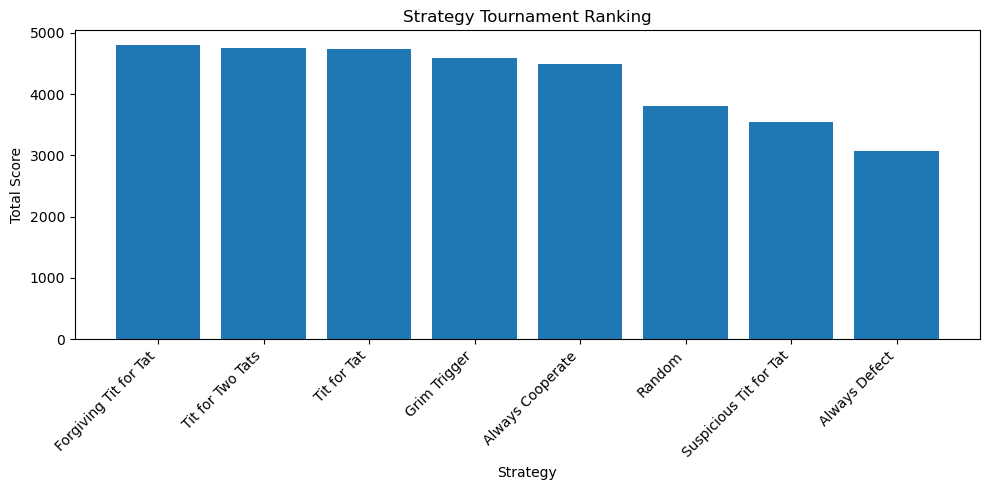

WindowsPath('C:/Users/viktus/Desktop/for_labs/trust-duel-rl-game/reports/figures/strategy_tournament_ranking.png')

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(ranking["strategy"], ranking["total_score"])
plt.title("Strategy Tournament Ranking")
plt.xlabel("Strategy")
plt.ylabel("Total Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

ranking_path = FIGURES_DIR / "strategy_tournament_ranking.png"
plt.savefig(ranking_path, dpi=150)
plt.show()

ranking_path


## 6. Cumulative Reward Example

A cumulative reward chart helps us see how performance changes over repeated rounds.


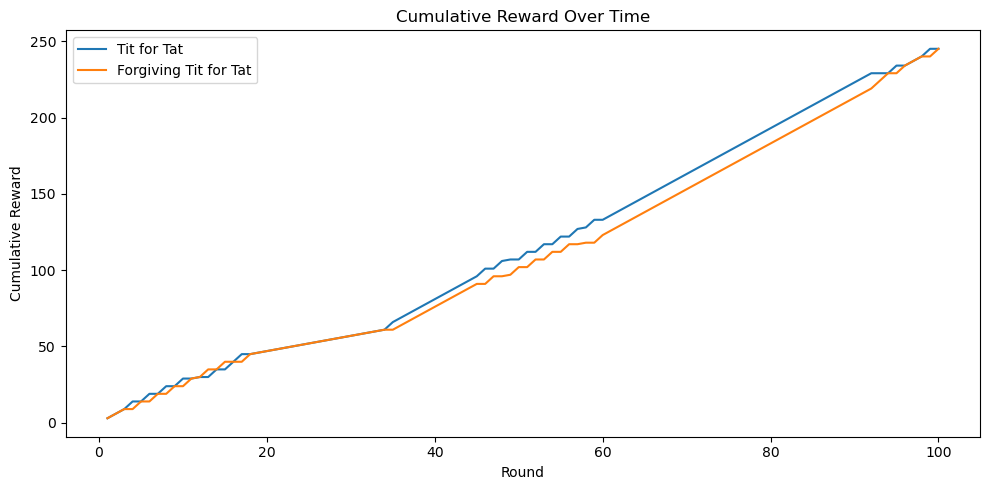

,round,player_a,player_b,intended_a,intended_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
95,96,Tit for Tat,Forgiving Tit for Tat,C,D,C,D,0,5,234,234
96,97,Tit for Tat,Forgiving Tit for Tat,D,C,C,C,3,3,237,237
97,98,Tit for Tat,Forgiving Tit for Tat,C,C,C,C,3,3,240,240
98,99,Tit for Tat,Forgiving Tit for Tat,C,C,D,C,5,0,245,240
99,100,Tit for Tat,Forgiving Tit for Tat,C,D,C,D,0,5,245,245


In [7]:
example_match = simulate_match(
    TitForTat(),
    ForgivingTitForTat(forgiveness=0.1, seed=7),
    rounds=100,
    noise=0.05,
    seed=7,
)

plt.figure(figsize=(10, 5))
plt.plot(example_match["round"], example_match["cumulative_a"], label="Tit for Tat")
plt.plot(example_match["round"], example_match["cumulative_b"], label="Forgiving Tit for Tat")
plt.title("Cumulative Reward Over Time")
plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.tight_layout()

cumulative_path = FIGURES_DIR / "cumulative_reward_example.png"
plt.savefig(cumulative_path, dpi=150)
plt.show()

example_match.tail()


## 7. Human vs Agent Game

This is the person-vs-agent part.

The function below lets a human play against a fixed strategy agent.

In a normal notebook, run the cell and type:

- `C` for cooperate
- `D` for defect


In [8]:
def play_human_vs_agent(agent_strategy, rounds=10):
    human_history = []
    agent_history = []
    human_score = 0
    agent_score = 0

    print(f"You are playing against: {agent_strategy.name}")
    print("Type C to cooperate or D to defect.\n")

    for round_idx in range(1, rounds + 1):
        human_action = input(f"Round {round_idx} — Your action (C/D): ").strip().upper()

        while human_action not in ["C", "D"]:
            human_action = input("Invalid input. Please type C or D: ").strip().upper()

        agent_action = agent_strategy.choose_action(agent_history, human_history)

        reward_human, reward_agent = PAYOFFS[(human_action, agent_action)]

        human_history.append(human_action)
        agent_history.append(agent_action)

        human_score += reward_human
        agent_score += reward_agent

        print(
            f"Human: {human_action} | Agent: {agent_action} "
            f"| Reward: Human {reward_human}, Agent {reward_agent} "
            f"| Total: Human {human_score}, Agent {agent_score}"
        )

    return pd.DataFrame(
        {
            "round": range(1, rounds + 1),
            "human_action": human_history,
            "agent_action": agent_history,
        }
    )

# Uncomment to play:
# human_game = play_human_vs_agent(TitForTat(), rounds=10)
# human_game


## 8. Q-Learning Agent

Now we train a simple tabular Q-learning agent.

The Q-agent observes a state based on previous actions:

```text
state = (my_previous_action, opponent_previous_action)
```

Then it chooses one of two actions:

```text
C = Cooperate
D = Defect
```

The agent receives reward from the payoff matrix and updates its Q-table.


In [9]:
agent, training_log = train_q_agent(
    opponent_strategy=TitForTat(),
    episodes=1000,
    rounds_per_episode=100,
    seed=42,
)

training_log.head()


,episode,total_reward,epsilon
0,1,240,0.995000
1,2,240,0.990025
2,3,225,0.985075
3,4,239,0.980150
4,5,221,0.975249


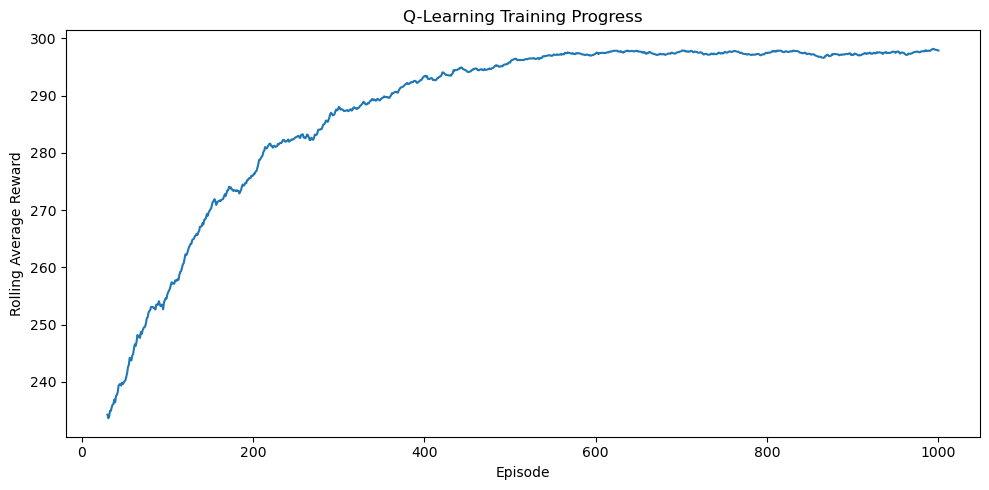

,episode,total_reward,epsilon
995,996,296,0.05
996,997,299,0.05
997,998,298,0.05
998,999,298,0.05
999,1000,296,0.05


In [10]:
plt.figure(figsize=(10, 5))
plt.plot(training_log["episode"], training_log["total_reward"].rolling(30).mean())
plt.title("Q-Learning Training Progress")
plt.xlabel("Episode")
plt.ylabel("Rolling Average Reward")
plt.tight_layout()

training_path = FIGURES_DIR / "q_learning_training_progress.png"
plt.savefig(training_path, dpi=150)
plt.show()

training_log.tail()


## 9. Inspect the Q-Table

The Q-table stores the learned value of each action in each state.

Higher Q-value means the agent expects higher future reward from that action.


In [11]:
q_table_df = agent.q_table_dataframe()
q_table_df


,state_my_previous,state_opponent_previous,Q_C,Q_D,best_action
0,START,START,60.0,59.149454,C
1,D,C,57.0,55.150000,C
2,C,D,60.0,59.150000,C
3,C,C,60.0,59.150000,C
4,D,D,57.0,55.150000,C


## 10. Evaluate Trained Q-Agent

Now we wrap the trained Q-learning agent as a strategy and let it play a normal match.


In [12]:
trained_q_strategy = TrainedQAgentStrategy(agent)

q_eval_match = simulate_match(
    trained_q_strategy,
    TitForTat(),
    rounds=100,
    noise=0.0,
    seed=123,
)

q_eval_match.tail()


,round,player_a,player_b,intended_a,intended_b,action_a,action_b,reward_a,reward_b,cumulative_a,cumulative_b
95,96,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,288,288
96,97,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,291,291
97,98,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,294,294
98,99,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,297,297
99,100,Trained Q-Agent,Tit for Tat,C,C,C,C,3,3,300,300


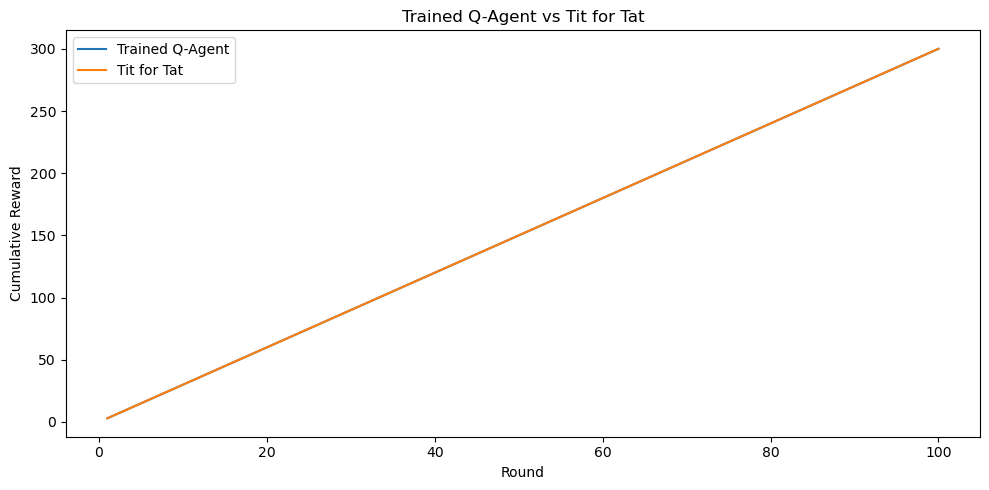

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(q_eval_match["round"], q_eval_match["cumulative_a"], label="Trained Q-Agent")
plt.plot(q_eval_match["round"], q_eval_match["cumulative_b"], label="Tit for Tat")
plt.title("Trained Q-Agent vs Tit for Tat")
plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.tight_layout()

q_eval_path = FIGURES_DIR / "trained_q_agent_vs_tit_for_tat.png"
plt.savefig(q_eval_path, dpi=150)
plt.show()


## 11. Train Q-Agent Against a Pool of Strategies

Training against one opponent can make the Q-agent too specialized.

Here we train it against a pool of different opponents.


In [14]:
pool = [
    AlwaysCooperate(),
    AlwaysDefect(),
    RandomStrategy(p_defect=0.5, seed=42),
    TitForTat(),
    GrimTrigger(),
    ForgivingTitForTat(forgiveness=0.1, seed=42),
]

pool_agent, pool_training_log = train_q_agent_against_pool(
    pool,
    episodes=1500,
    rounds_per_episode=100,
    seed=42,
)

pool_training_log.head()


,episode,total_reward,epsilon,opponent
0,1,392.0,0.995000,Always Cooperate
1,2,240.0,0.990025,Tit for Tat
2,3,217.0,0.985075,Random
3,4,398.0,0.980150,Always Cooperate
4,5,49.0,0.975249,Always Defect


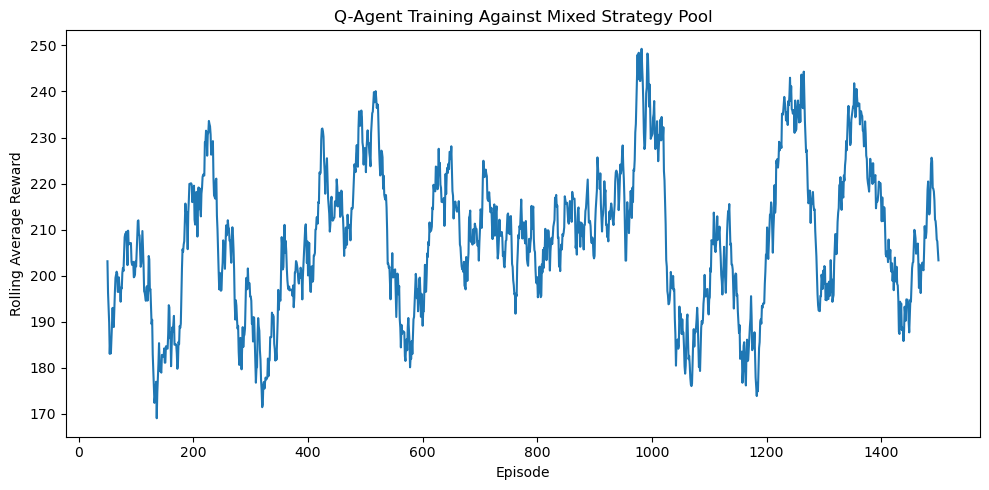

,state_my_previous,state_opponent_previous,Q_C,Q_D,best_action
0,START,START,48.298868,43.907064,C
1,D,C,36.412845,31.396490,C
2,C,C,36.501834,36.284209,C
3,C,D,26.637672,34.685508,D
4,D,D,34.654890,28.230578,C


In [15]:
plt.figure(figsize=(10, 5))
plt.plot(pool_training_log["episode"], pool_training_log["total_reward"].rolling(50).mean())
plt.title("Q-Agent Training Against Mixed Strategy Pool")
plt.xlabel("Episode")
plt.ylabel("Rolling Average Reward")
plt.tight_layout()

pool_training_path = FIGURES_DIR / "q_agent_pool_training.png"
plt.savefig(pool_training_path, dpi=150)
plt.show()

pool_agent.q_table_dataframe()


## 12. Final Interpretation

This project demonstrates that reinforcement learning can be represented as repeated interaction between an agent and an environment.

Main concepts:

- The **agent** chooses actions.
- The **environment** gives rewards.
- The **state** summarizes the current situation.
- The **policy** decides what action to take.
- The **Q-table** stores learned action values.
- The agent balances **exploration** and **exploitation**.

Game theory insight:

There is no universally best strategy.  
A strategy that performs well in a cooperative environment may perform badly in a hostile or noisy environment.

In repeated games, strong strategies often combine:

- cooperation,
- retaliation,
- forgiveness,
- clarity,
- adaptability.
